In [1]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("drawndata2.csv")
X, y = df[["x","y"]].values, df["z"] == "a"

In [3]:
df.head()

,x,y,z
0,469.759355,453.574946,a
1,535.331819,435.221848,a
2,504.285526,437.767578,a
3,469.891398,368.371652,a
4,405.425622,403.141546,a


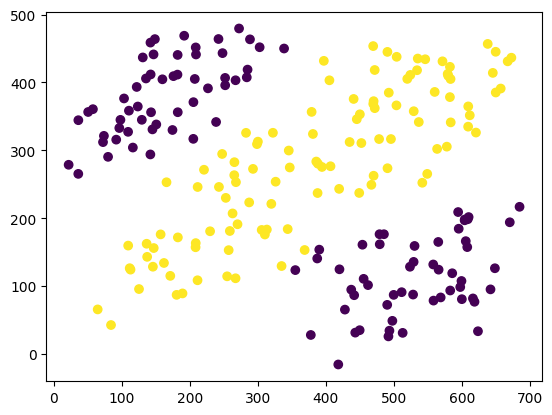

In [4]:
plt.scatter(X[:,0],X[:,1],c=y)

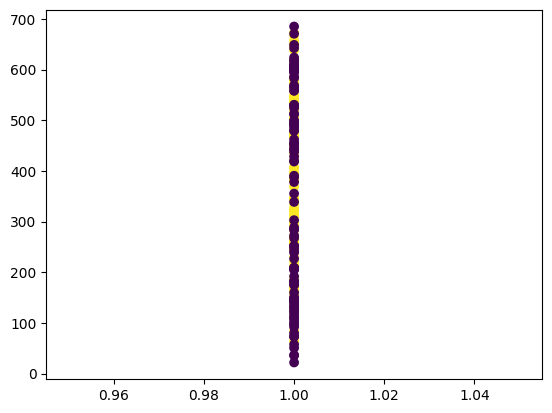

In [5]:
from sklearn.preprocessing import StandardScaler, QuantileTransformer, PolynomialFeatures
scaler = PolynomialFeatures() # QuantileTransformer()
X_new = scaler.fit_transform(X)
plt.scatter(X_new[:,0],X_new[:,1],c=y)

In [6]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
pipe = Pipeline([
        ("scale", scaler),
        ("model", LogisticRegression())
        # ("model", KNeighborsClassifier(n_neighbors=20, weights='distance'))
    ])
pipe.fit(X,y)

,steps,"[('scale', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,degree,2
,interaction_only,False
,include_bias,True
,order,'C'
,penalty,'l2'
,dual,False
,tol,0.0001


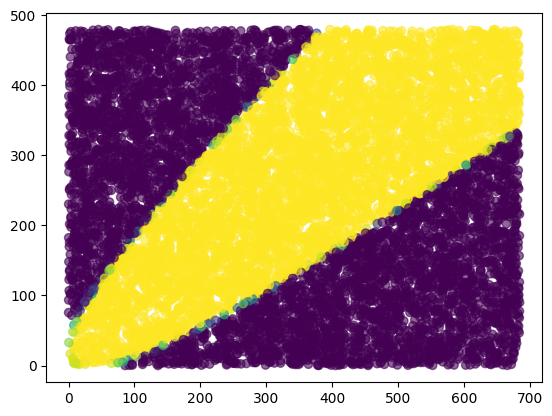

In [ ]:
X_test = np.concatenate([
        np.random.uniform(0, X[:, 0].max(), (10000, 1)), 
        np.random.uniform(0, X[:, 1].max(), (10000, 1))
    ], axis=1)
y_proba = pipe.predict_proba(X_test)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_proba[:, 1], alpha=0.6)